In [1]:
#Si estas en colab, corre esta celda para instalar las librerias
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer

In [2]:


from qiskit_aer import AerSimulator
backend =  AerSimulator(method='statevector')

# Sesión 5 Laboratorio de Computación Cuántica 2

## Algoritmo de Simon

El Algoritmo de Simon es otro algoritmo que permite que nosotros veamos la ventaja cuántica directamente en el sistema. Vamos a presentar primero el problema de Simon y despues como el algoritmo de Simon lo trabaja y resuelve.

### Recordatorio: Producto punto módulo 2 de strings

Sea $x \cdot s$ el producto interno de strings modulo 2

Si $x = 1110$ and $s = 1010$, entonces $x\cdot s = 1.1 + 1.0 + 1.1 + 0.0 = 1+0+1+0= 2 \pmod 2 = 0$

### Operación XOR bit a bit

También conocida como adición por Bit 2 a 2, esta operación es una operación matemática que nos permite representar sumas entre diversos strings cuando se realiza bit por bit. Aquí tenemos un ejemplo de como se visualiza dicha suma para strings $a_1,...,a_4$

Sea $a_{1}=101, a_{2}=011, a_{3}=100,  a_{4}=000$.

$a_1 \oplus a_2 = (1,0,1) \oplus (0,1,1) = (1\oplus 0, 0 \oplus 1, 1 \oplus 1) = 110$

$a_1 \oplus a_3 = (1,0,1) \oplus (1,0,0) = (1\oplus 1, 0 \oplus 0, 1 \oplus 0) = 001$

$a_2 \oplus a_3 = (0,1,1) \oplus (1,0,0) = (0\oplus 1, 1 \oplus 0, 1 \oplus 0) = 111$  

$a_1 \oplus a_4 = (1,0,1) \oplus (0,0,0) = (1\oplus 0, 0 \oplus 0, 1 \oplus 0) = 101$ 

Actividad: $a_1=011010$, $a_2=110101$, calcula las 2 operaciones.

$a_1 \oplus a_2$=101111

$a_1 \cdot a_2$=1

### Problema de Simon

El algoritmo de Simon estudia una familia específica de funciones

$$
f:\{0,1\}^n \rightarrow \{0,1\}^n
$$

que cumplen una de las siguientes dos condiciones.

Primera condición:

$$
f \text{ es inyectiva}
$$

lo cual significa

$$
f(x) = f(y) \Rightarrow x = y
$$

Segunda condición:

Una función $f(x)$ es 2 a 1 si para 2 valores de su dominio existe un solo valor relacionado en el contradominio

$f$ es una función $2$ a $1$ con periodo $s$. Es decir, existe un string no nulo $s$ tal que

$$
f(x) = f(y) \iff y = x \oplus s
$$

El algoritmo de Simon busca que nosotros identifiquemos de la forma mas rápida posible si la función es inyectiva o 2-a-1 con esta condición, mientras que ademas identificamos el valor del string $s$ con la menor cantidd posible de ejecuciones de $f(x)$

### Solución clásica al problema de Simon

La forma mas sencilla de realizar eso, es iterar sobre todos los posibles valores de $x$ que tengas hasta que encuentres 2 valores que cumplan que $f(x)=f(y)$. Una vez haces esto, solamente basta con calcular $x\oplus y$ para encontrar el valor de s

Actividad de tarea 2: Demuestra que si tenemos una función 2-a-1 del tipo que Simon estudia, de modo que $f(x)=f(x\oplus s)$ para algún string $s$ dado, entonces dados $x$ y $y$ tales que $f(x)=f(y)$, $x\neq y$, entonces $x\oplus y=s$

Esta solución tiene el detalle de, si $n$ es la longitud de los bitstrings que estamso trabajando, entonces si no tenemos suerte, tenemos que hacer $2^{n-1}+1$ iteraciones de esto. Es decir, la complejidad es del orden de $O(2^{n-1})$

### Recordatorio: Oráculo cuántico

En mecánica cuántica, la operación que aplique debe ser una compuerta unitaria, es decir:

$$
U^\dagger U = I
$$

Esto implica que la compuerta tiene que ser reversible. Sin embargo, en general, una función clásica $f$ no es reversible.

### Solución: Oráculo reversible

Creamos un oráculo reversible $U_f$ tal que:

$$
U_f |x\rangle |y\rangle \longrightarrow |x\rangle |y \oplus f(x)\rangle
$$

Donde $\oplus$ equivale a una suma bit a bit, es decir, la operación XOR.

Ejemplo:

$$
|101\rangle \oplus |011\rangle = |110\rangle
$$

Es decir, suma entrada por entrada en binario, equivalente a aplicar una compuerta XOR bit a bit.



El funcionamiento del algoritmo depende a partir de ahora de la implementación del Oráculo. Y en esta ocasión lo vamos a aplicar al circuito del lagoritmo de Simon



### Circuito cuántico del Algoritmo de Simon

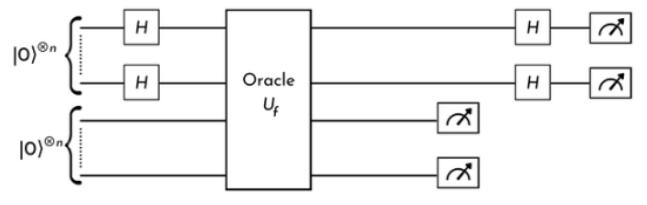

Vamos a desarrollar la matemática detrás del algoritmo de Simon, tenemos 2 registros cuánticos, cada uno con $n$ qubits. El estado inicial esta dado por:
$$ |{\psi_0}⟩ = |{0}⟩^{\otimes n} |{0}⟩^{\otimes n}$$


Corremos las compuertas Hadamard en el primer registro, lo cual, como sabemos, genera

$$ |{\psi_1}⟩ = \frac{1}{\sqrt{2^{n}}}\sum_{x ∈ \left\{0,1\right\}^{n}}|x⟩ |0⟩^{\otimes n} $$

Tras ello, aplicamos el oráculo al sistema. La aplicación del oráculo como ya sabemos, nos genera esto:

$$ |{\psi_2}⟩ = \frac{1}{\sqrt{2^{n}}}\sum_{x ∈ \left\{0,1\right\}^{n}}|x⟩ |𝑓(x)⟩ $$

Tras ello, realizamos medición del Segundo registro. Esta medición lo que hace es que forza al sistema de las $|f(x)\rangle$ a colapsar, pero esto va a variar en el caso de que la función es inyectiva o 2-a-1

#### Caso 1: Función 2-a-1

Si la función es 2-a-1, entonces para cada $f(z)$ existen 2 valores z asociados, $z$ y $z \oplus s$

$$ |{\psi_3}⟩ = \frac{1}{\sqrt{2}}(\ket{z}+\ket{z\oplus s})\ket{f(z)} $$

Tras ello, aplicamos compuerta Hadamard al primer registro. Recuerda que
$$H^{\otimes n}\ket{z} =  \frac{1}{\sqrt{2^n}} \sum_{y \in \{0,1\}^n} (-1)^{z \cdot y}\ket{y}$$

De modo que, aplicando las compuertas hadamard al primer registro e ignorando al segundo registro, recuperamos la sig expresión:

$$|{\psi_4}⟩ = \frac{1}{\sqrt{2^{n+1}}}\sum_{y ∈ \left\{0,1\right\}^{n}}[(-1)^{z \cdot y}+(-1)^{(z\oplus s) \cdot y}]\ket{y} $$

Ahora notemos algo importante. Si $(-1)^{z\cdot y}\neq (-1)^{(z\oplus s) \cdot y}$, entonces la probabilidad de mediy $|y\rangle$ es 0, de modo que para que se pueda medir ese resultado, necesitamos que $(-1)^{z\cdot y}= (-1)^{(z\oplus s) \cdot y}$ y en consecuencia, que se cumpla que $z\cdot y = (z\oplus s) \cdot y$

Actividad para Tarea 3: Demuestra que $ (z \oplus s) \cdot y = (z \cdot y) \oplus (s \cdot y). $

De modo que para que $z\cdot y = (z\oplus s) \cdot y$ por la propiedad dada antes, entonces $s\cdot y=0$

Entonces, si $s\cdot y=0$, se sigue que $[(-1)^{z \cdot y}+(-1)^{(z\oplus s) \cdot y}]=2$ por lo cual el coeficiente de $\ket{y}$ se vuelve $\frac{2}{\sqrt{2^{n+1}}}$ de donde la probabilidad de medir dicho valor se vuelve $\frac{1}{2^{n-1}}$. Eso quiere decir que observaremos todos los strings que cumplan que $s\cdot y=0$ mientras que strings que cumplan que $s \cdot y= 1$ no los mediremos en absoluto

#### Caso 2: Función inyectiva

Aquí, el estado tras medir el segundo registro es simplemente $$ \ket{{\psi_3}} =\ket{z}\ket{f(z)} $$

entonces, al aplicar Hadamards en el primer registro, solo obtendremos

$$\ket{{\psi_4}} = \frac{1}{\sqrt{2^{n}}}\sum_{y ∈ \left\{0,1\right\}^{n}}(-1)^{z \cdot y}\ket{y}.$$

lo cual quiere decir que obtendremos todos los strings con igual probabilidad

### Recuperación de s

La clave aquí es que, si queremos recuperar $s$ dada una función 2-a-1, al realizar las mediciones del sistema vamos a recuperar diversos valores de $|y\rangle$ que cada y se podra ver como un string, de donde tendremos un conjunto de strings $\{y^1,...,y^{n-1}\}$ de manera que cada uno de estos cumpla la condición que $y^i\cdot s= 0$

Ejemplos de oráculos:

In [3]:
def oracle_s100(): #Aplicamos la función oráculo de Simon para el caso s = 100, f(x1,x2,x3) = (x2,x3,0)

    oracle = QuantumCircuit(6)

    oracle.cx(1,3)   # y0 = x2
    oracle.cx(2,4)   # y1 = x3

    return oracle

$x_1, x_2, x_3$ $0,0,0$, $CNOT(x_1,0)=(x_1, \oplus x_1)$

In [4]:
def oracle_s110(): # s = 110
                   # f(x1,x2,x3) = (x1⊕x2, x3, 0)
                   # Cambiar x1 y x2 simultáneamente (⊕110)
                   # deja x1⊕x2 sin cambio

    oracle = QuantumCircuit(6)

    oracle.cx(0,3)   # y0 = x1
    oracle.cx(1,3)   # y0 = x1 ⊕ x2

    oracle.cx(2,4)   # y1 = x3

    return oracle

In [5]:
def oracle_s101(): # s = 101
                   # f(x1,x2,x3) = (x1⊕x3, x2, 0)
                   # Cambiar x1 y x3 simultáneamente (⊕101)
                   # deja x1⊕x3 sin cambio

    oracle = QuantumCircuit(6)

    oracle.cx(0,3)   # y0 = x1
    oracle.cx(2,3)   # y0 = x1 ⊕ x3

    oracle.cx(1,4)   # y1 = x2

    return oracle

In [6]:
def oracle_s001(): # s = 001
                   # f(x1,x2,x3) = (x1,x2,0)
                   # La función no depende de x3
                   # Por lo tanto f(x) = f(x ⊕ 001)

    oracle = QuantumCircuit(6)

    oracle.cx(0,3)   # y0 = x1
    oracle.cx(1,4)   # y1 = x2

    return oracle

Constructor general de oráculos de Simon

In [7]:
def simon_oracle(s):
    n = len(s)
    oracle = QuantumCircuit(2*n)
    
    # copiar x en el registro de salida
    for i in range(n):
        oracle.cx(i, i+n)

    # introducir la dependencia con s
    for i, bit in enumerate(s):
        if bit == '1':
            oracle.cx(0, i+n)

    return oracle

Actividad para Tarea 4: Explica que hace la función $simon\_oracle(s)$ del notebook y por que siempre nos recupera un oráculo 2-a-1 y que hace si el string s solo tiene 0. Explicalo en tus propias palabras y haz la demostración matemática.

Esqueleto del algoritmo de Simon ya dados los oráculos para trabajar

In [8]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

# Definimos 2 registros cuánticos de 3 qubits cada uno y un registro clásico de 3 bits
qreg1 = QuantumRegister(3, "register_1")
qreg2 = QuantumRegister(3, "register_2")
creg = ClassicalRegister(3)

# Fabricamos el circuito de Simon
simon_circuit = QuantumCircuit(qreg1, qreg2, creg)



In [9]:
# Aplicamos Hadamard a la primera parte del circuito
simon_circuit.h(qreg1)
simon_circuit.barrier()

# Aplicamos la función oráculo de Simon
simon_circuit.compose(oracle_s100(), inplace=True)
simon_circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=6, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "register_1"), index=0>, <Qubit register=(3, "register_1"), index=1>, <Qubit register=(3, "register_1"), index=2>, <Qubit register=(3, "register_2"), index=0>, <Qubit register=(3, "register_2"), index=1>, <Qubit register=(3, "register_2"), index=2>), clbits=())

In [10]:
# Medimos la segunda parte del circuito para colapsar el estado
simon_circuit.measure(qreg2, creg)
simon_circuit.barrier()

# Aplicamos Hadamard a la primera parte del circuito
simon_circuit.h(qreg1)
simon_circuit.barrier()

# Medimos la primera parte del circuito
simon_circuit.measure(qreg1, creg)



In [11]:
# Ejecutamos el circuito
simulator = AerSimulator(method='statevector')
job = simulator.run(simon_circuit, shots=1)
result = job.result()
counts = result.get_counts()

# Como shots = 1, solo hay una clave
output = list(counts.keys())[0]

print("Resultado:", output)

# Dibujar circuito (opcional)
print(simon_circuit.draw('mpl'))

Resultado: 010
Figure(1418.03x618.722)


Podemos condensar todo en una función que podamos llamar y ejecutar cuando se nos plazca

In [12]:
def simon(simon_oracle):
    # Definimos 2 registros cuánticos de 3 qubits cada uno y un registro clásico de 3 bits
    qreg1 = QuantumRegister(3, "register_1")
    qreg2 = QuantumRegister(3, "register_2")
    creg = ClassicalRegister(3)

    # Fabricamos el circuito de Simon
    simon_circuit = QuantumCircuit(qreg1, qreg2, creg)

    # Aplicamos Hadamard al primer registro
    simon_circuit.h(qreg1)
    simon_circuit.barrier()

    # Aplicamos la función oráculo de Simon
    simon_circuit.compose(simon_oracle(), inplace=True) 
    simon_circuit.barrier()
    
    # Medimos el segundo registro para colapsar el estado
    simon_circuit.measure(qreg2,creg)
    simon_circuit.barrier()

    # Aplicamos Hadamard al primer registro
    simon_circuit.h(qreg1)
    simon_circuit.barrier()

    # Medimos el primer registro
    simon_circuit.measure(qreg1,creg)
    
    job = AerSimulator().run(simon_circuit,shots=1)
    counts = job.result().get_counts()
    
    # Como shots = 1, solo hay una clave
    return list(counts.keys())[0]

In [36]:
n = 3
y_list = []
it = 1

def oraculo():
    return simon_oracle('101') 

while(len(y_list)) < n-1:
    y = simon(oracle_s101) 
    if y!='000' and y not in y_list: #omitimos el string 000
        y_list.append(y) #Guardamos la clave y en la lista de y's
    it+=1


print(y_list)
print(f"Tomó {it} iteraciones para obtener la lista de y's")

['111', '101']
Tomó 4 iteraciones para obtener la lista de y's


$y^1$=100
$y^2$=010

$y^1 \cdot s=0 \Rightarrow y^1_1*s_1 + y^1_2*s_2+y^1_3*s_3=0$


$y^2 \cdot s=0 \Rightarrow y^2_1*s_1 + y^2_2*s_2 + y^2_3*s_3=0$

$s_1=0, s_2=0, s_3=1$

Y como qiskit invierte el orden:

s=100 tal como predecimos

Actividad para tarea 5: Piensa en 3 funciones 2-a-1 para los siguientes 3 strings. s=1010, s=1101, s=1111 y fabrica el oráculo de las mismas. Recupera los strings utilizando Simon y resuelve el sistema de ecuaciones con el método que tu quieras. No olvides que Qiskit invierte el orden de los strings


Actividad para tarea 6: Genera 2 oráculos de funciones 1-a-1 y corrobora que simon nos regresa todos los strings con igual probabilidad, y compara con 2 oráculos de funciones 2-a-1 (puedes usar los que ya estan en el notebook). Puedes hacerlo de la forma que tu quieras, pero te recomiendo que hagas histogramas de las mediciones que recuperaste para comparar los datos de las mediciones. Coloca el código del algoritmo, del oráculo y de todas las gráficas de forma ordenada y clara. 